# 한국어 위키피디아 데이터 정제

이 노트북은 한국어 위키피디아 XML 덤프 파일을 정제하고 Hugging Face에 업로드합니다.

## 작업 목표
- XML 덤프 파싱 및 필터링
- 위키텍스트 정제 (마크업 제거, 불필요한 섹션 제거)
- 정제된 데이터 저장 및 통계 확인
- Hugging Face에 정제된 데이터 업로드


In [120]:
# 필요한 라이브러리 import
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import json
from tqdm import tqdm
warnings.filterwarnings('ignore')

# 프로젝트 루트 경로 추가
project_root = Path().resolve().parent.parent  # notebooks/experiments -> notebooks -> 프로젝트 루트
sys.path.insert(0, str(project_root))

from src.data.wikipedia_parser import parse_wikipedia_xml_stream, is_redirect, is_stub

# 모듈 변경사항 반영을 위해 다시 import
import importlib
import src.data.wikipedia_cleaner
importlib.reload(src.data.wikipedia_cleaner)
from src.data.wikipedia_cleaner import clean_wikitext

# 데이터 경로
xml_path = project_root / 'data' / 'kowiki-20251220-pages-articles-multistream.xml'
output_dir = project_root / 'data' / 'cleaned_datasets'
output_dir.mkdir(parents=True, exist_ok=True)

print(f"프로젝트 루트: {project_root}")
print(f"XML 파일 경로: {xml_path}")
print(f"출력 디렉토리: {output_dir}")
print(f"XML 파일 존재: {xml_path.exists()}")


프로젝트 루트: /data/ephemeral/home/T8001/pro-nlp-generationfornlp-nlp-07
XML 파일 경로: /data/ephemeral/home/T8001/pro-nlp-generationfornlp-nlp-07/data/kowiki-20251220-pages-articles-multistream.xml
출력 디렉토리: /data/ephemeral/home/T8001/pro-nlp-generationfornlp-nlp-07/data/cleaned_datasets
XML 파일 존재: True


## 테스트: 한 페이지만 정제해보기

정제 로직이 제대로 작동하는지 확인하기 위해 한 페이지만 정제해봅니다.


In [121]:
idx = 2

min_korean_ratio = None
min_text_length = 200

# 한 페이지만 가져와서 정제 테스트
print("한 페이지만 가져오는 중...")
page_iterator = parse_wikipedia_xml_stream(str(xml_path), max_pages=idx, sample_rate=1.0)
for _ in range(idx-1):
    next(page_iterator, None)
test_page = next(page_iterator, None)

print(f"\n원본 페이지 정보:")
print(f"  제목: {test_page.get('title', 'N/A')}")
print(f"  네임스페이스: {test_page.get('ns', 0)}")
print(f"  페이지 ID: {test_page.get('page_id', 'N/A')}")
print(f"  원본 텍스트 길이: {len(test_page.get('text', '')):,}자")

# 원본 텍스트 미리보기
original_text = test_page.get('text', '')
print(f"\n원본 텍스트 미리보기")
print("-" * 60)
print(original_text)
print("-" * 60)

# 정제 실행
print(f"\n정제 중...")
cleaned_text = clean_wikitext(original_text, debug=True)

print(f"\n정제 결과:")
print(f"  원본 길이: {len(original_text):,}자")
print(f"  정제 후 길이: {len(cleaned_text):,}자")
print(f"  감소율: {(1 - len(cleaned_text)/len(original_text))*100:.1f}%")

print(f"\n정제된 텍스트:")
print("-" * 60)
print(cleaned_text)
print("-" * 60)

# 필터링 체크
print(f"\n필터링 체크:")
print(f"  리다이렉트 여부: {is_redirect(original_text)}")
print(f"  스텁 여부: {is_stub(cleaned_text)}")
print(f"  최소 길이 통과: {len(cleaned_text) >= min_text_length}")

if min_korean_ratio is not None:
    korean_count = len(re.findall(r'[가-힣]', cleaned_text))
    total_chars = len(cleaned_text)
    korean_ratio = korean_count / total_chars if total_chars > 0 else 0
    print(f"  한글 비율: {korean_ratio*100:.1f}% (필요: {min_korean_ratio*100:.1f}%)")
    print(f"  한글 비율 통과: {korean_ratio >= min_korean_ratio}")


한 페이지만 가져오는 중...
XML 파일 열기 중... (파일 크기: 5.60 GB)
XML 파서 초기화 중...
파싱 시작...

원본 페이지 정보:
  제목: 지미 카터
  네임스페이스: 0
  페이지 ID: 5
  원본 텍스트 길이: 42,233자

원본 텍스트 미리보기
------------------------------------------------------------
{{대통령 정보
| 이름 = 지미 카터
| 원어명 = {{lang|en|Jimmy Carter}}
| 그림 = JimmyCarterPortrait.jpg
| 크기 = 300px
| 설명 = 
| 국가 = 미국
| 대수 = 39
| 취임일 = 1977년 1월 20일
| 퇴임일 = 1981년 1월 20일
| 부통령 = [[월터 먼데일]]
| 전임 = 제럴드 포드
| 전임대수 = 38
| 후임 = 로널드 레이건
| 후임대수 = 40
<!--주지사-->| 국가2 = [[조지아주]]
| 명칭2 = [[주지사]]
| 대수2 = 76
| 취임일2 = 1971년 1월 12일
| 퇴임일2 = 1975년 1월 14일
| 부통령2 = 레스터 매독스
| 부통령명칭2 = 부주지사
| 전임2 = 레스터 매독스
| 전임대수2 = 
| 후임2 = 조지 버스비
| 후임대수2 = <!--주의회 상원 의원-->
| 공직2 = [[조지아주]] 의회
| 공직2명칭 = 주 상원 의원(제14구역)
| 공직2대수 = 
| 공직2취임일 = 1963년 1월 14일
| 공직2퇴임일 = 1967년 1월 10일
| 공직2전임 = 
| 공직2후임 = 휴 카터
| 국적 = [[미국]]
| 출생일 = {{출생일|1924|10|1}}
| 출생지 = [[미국]] [[조지아주]] [[플레인스 (조지아)|플레인스]]
| 사망일 = {{사망일과 나이|2024|12|29|1924|10|1}}
| 사망지 = 
| 정당 = [[민주당 (미국)|민주당]]
| 학력 = [[조지아 남서 주립대학교]]<br />[[조지아 공과대학교]]<br />[[유니언 

## 정제 작업 실행

정제 파라미터를 설정하고 실행합니다.


In [126]:
# 정제 파라미터 설정
min_text_length = 200  # 정제 후 최소 텍스트 길이
namespace = 0  # 일반 문서만 (0 = main namespace)
max_pages = None  # 전체 처리 (테스트 시에는 작은 수로 설정, 예: 1000)
sample_rate = 1.0  # 전체 샘플링
min_korean_ratio = None  # 한글 비율 필터링 (None = 비활성화, 예: 0.5 = 50% 이상)

print("정제 설정:")
print(f"  min_text_length: {min_text_length}")
print(f"  namespace: {namespace}")
print(f"  max_pages: {max_pages}")
print(f"  sample_rate: {sample_rate}")
print(f"  min_korean_ratio: {min_korean_ratio}")


정제 설정:
  min_text_length: 200
  namespace: 0
  max_pages: None
  sample_rate: 1.0
  min_korean_ratio: None


In [127]:
# 정제 작업 실행
# 통계 초기화
stats = {
    'total_pages': 0,
    'filtered_pages': 0,
    'cleaned_pages': [],
    'text_lengths': [],
    'korean_ratios': [],
}

print(f"Processing Wikipedia XML dump: {xml_path}")
print(f"Filters: namespace={namespace}, min_length={min_text_length}, "
      f"max_pages={max_pages}, sample_rate={sample_rate}")

# 페이지 처리
for page in tqdm(
    parse_wikipedia_xml_stream(str(xml_path), max_pages, sample_rate),
    desc="Processing pages"
):
    stats['total_pages'] += 1
    
    # Filter by namespace
    if page.get('ns', 0) != namespace:
        continue
    
    # Get page content
    title = page.get('title', '')
    text = page.get('text', '')
    page_id = page.get('page_id')
    
    # Skip redirects and empty pages
    if not text or is_redirect(text):
        continue
    
    # Clean text
    cleaned_text = clean_wikitext(text)
    
    # Filter by minimum length
    if len(cleaned_text) < min_text_length:
        continue
    
    # Filter by Korean ratio if specified
    if min_korean_ratio is not None:
        korean_count = len(re.findall(r'[가-힣]', cleaned_text))
        total_chars = len(cleaned_text)
        if total_chars > 0:
            korean_ratio = korean_count / total_chars
            if korean_ratio < min_korean_ratio:
                continue
            stats['korean_ratios'].append(korean_ratio)
    
    # Skip stubs if they're too short after cleaning
    if is_stub(cleaned_text):
        continue
    
    stats['filtered_pages'] += 1
    stats['text_lengths'].append(len(cleaned_text))
    
    # Store cleaned page
    page_record = {
        'content': cleaned_text,
        'title': title,
        'page_id': page_id,
        'text_length': len(cleaned_text),
    }
    stats['cleaned_pages'].append(page_record)

print("\n" + "=" * 60)
print("정제 작업 완료!")
print("=" * 60)
print(f"전체 페이지 수: {stats['total_pages']:,}")
print(f"필터링 후 페이지 수: {stats['filtered_pages']:,}")
if stats['text_lengths']:
    avg_text_length = sum(stats['text_lengths']) / len(stats['text_lengths'])
    print(f"평균 텍스트 길이: {avg_text_length:.1f}자")
if stats['korean_ratios']:
    avg_korean_ratio = sum(stats['korean_ratios']) / len(stats['korean_ratios'])
    print(f"평균 한글 비율: {avg_korean_ratio * 100:.1f}%")
print("=" * 60)


Processing Wikipedia XML dump: /data/ephemeral/home/T8001/pro-nlp-generationfornlp-nlp-07/data/kowiki-20251220-pages-articles-multistream.xml
Filters: namespace=0, min_length=200, max_pages=None, sample_rate=1.0


Processing pages: 14it [00:00, 129.23it/s]

XML 파일 열기 중... (파일 크기: 5.60 GB)
XML 파서 초기화 중...
파싱 시작...


Processing pages: 2157147it [19:19, 1860.17it/s] 


정제 작업 완료!
전체 페이지 수: 2,157,147
필터링 후 페이지 수: 565,484
평균 텍스트 길이: 1871.8자


## 정제된 데이터 저장

정제된 데이터를 Parquet 파일로 저장합니다.


In [128]:
# 정제된 데이터를 DataFrame으로 변환하고 저장
df_cleaned = pd.DataFrame(stats['cleaned_pages'])

# Parquet 파일로 저장
cleaned_file = output_dir / 'cleaned_pages.parquet'
df_cleaned.to_parquet(cleaned_file, compression='snappy', index=False)
print(f"정제된 데이터 저장 완료: {cleaned_file}")
print(f"저장된 페이지 수: {len(df_cleaned):,}개")

# 메타데이터 저장
avg_text_length = sum(stats['text_lengths']) / len(stats['text_lengths']) if stats['text_lengths'] else 0
avg_korean_ratio = sum(stats['korean_ratios']) / len(stats['korean_ratios']) if stats['korean_ratios'] else None

metadata = {
    'statistics': {
        'total_pages': stats['total_pages'],
        'filtered_pages': stats['filtered_pages'],
        'avg_text_length': avg_text_length,
        'avg_korean_ratio': avg_korean_ratio,
    },
    'config': {
        'min_text_length': min_text_length,
        'namespace': namespace,
        'max_pages': max_pages,
        'sample_rate': sample_rate,
        'min_korean_ratio': min_korean_ratio,
    },
}

metadata_file = output_dir / "metadata.json"
with open(metadata_file, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f"메타데이터 저장 완료: {metadata_file}")


정제된 데이터 저장 완료: /data/ephemeral/home/T8001/pro-nlp-generationfornlp-nlp-07/data/cleaned_datasets/cleaned_pages.parquet
저장된 페이지 수: 565,484개
메타데이터 저장 완료: /data/ephemeral/home/T8001/pro-nlp-generationfornlp-nlp-07/data/cleaned_datasets/metadata.json


## 정제된 데이터 확인

정제된 데이터를 로드하고 샘플을 확인합니다.


In [129]:
# 정제된 데이터 로드
cleaned_file = output_dir / 'cleaned_pages.parquet'
df_cleaned = pd.read_parquet(cleaned_file)

print(f"정제된 데이터 로드 완료: {len(df_cleaned):,}개 페이지")
print(f"\n컬럼: {df_cleaned.columns.tolist()}")
print(f"\n데이터 타입:")
print(df_cleaned.dtypes)
print(f"\n기본 통계:")
print(df_cleaned.describe())


정제된 데이터 로드 완료: 565,484개 페이지

컬럼: ['content', 'title', 'page_id', 'text_length']

데이터 타입:
content        object
title          object
page_id         int64
text_length     int64
dtype: object

기본 통계:
            page_id    text_length
count  5.654840e+05  565484.000000
mean   1.780280e+06    1871.777921
std    1.299453e+06    4495.494002
min    5.000000e+00     200.000000
25%    6.235208e+05     383.000000
50%    1.464072e+06     727.000000
75%    2.954671e+06    1671.000000
max    4.124107e+06  715796.000000


In [130]:
# 샘플 데이터 확인 (처음 5개)
print("=" * 60)
print("샘플 데이터 (처음 5개)")
print("=" * 60)
for idx, row in df_cleaned.head(5).iterrows():
    print(f"\n[{idx}] 제목: {row['title']}")
    print(f"    페이지 ID: {row.get('page_id', 'N/A')}")
    print(f"    텍스트 길이: {row['text_length']:,}자")
    print(f"    내용 미리보기 (처음 200자):")
    print(f"    {row['content'][:200]}...")
    print("-" * 60)


샘플 데이터 (처음 5개)

[0] 제목: 지미 카터
    페이지 ID: 5
    텍스트 길이: 14,098자
    내용 미리보기 (처음 200자):
    서훈 = 노벨 평화상(2002) **제임스 얼 "지미 카터 주니어"**(James Earl Jimmy Carter, Jr., 1924년 10월 1일~2024년 12월 29일)는 미국의 제39대 대통령 (1977-81)을 지낸 미국의 정치인이다.https://www.washingtonpost.com/obituaries/2024/12/29/jimmy-carte...
------------------------------------------------------------

[1] 제목: 수학
    페이지 ID: 9
    텍스트 길이: 6,348자
    내용 미리보기 (처음 200자):
    관련 직업 = 수학자 **수학**(數學, mathematics, math, maths)은 수, 양, 구조, 공간, 변화 등의 개념을 다루는 학문이다.url-status=live 수학의 주요 분야로는 산술(수를 연구하는 학문), 대수학(식과 수학적 구조를 다루는 학문), 기하학(도형과 공간을 연구하는 학문), 해석학(연속적인 변화와 그 성질을 연구하는 학문)...
------------------------------------------------------------

[2] 제목: 수학 상수
    페이지 ID: 10
    텍스트 길이: 3,501자
    내용 미리보기 (처음 200자):
    **수학**에서 **상수**(常數, constant)란 그 값이 변하지 않는 불변량으로, 변수의 반대말이다. 물리 상수와는 달리, 수학 상수는 물리적 측정과는 상관없이 정의된다. 수학 상수는 대개 실수체나 복소수체의 원소이다. 우리가 이야기할 수 있는 상수는 (거의 대부분 계산 가능한) 정의가능한 수이다. 특정 수학 상수, 예를 들면 골롬-딕맨 상수, 프랑...
---------------------------

## 텍스트 길이 분포 시각화


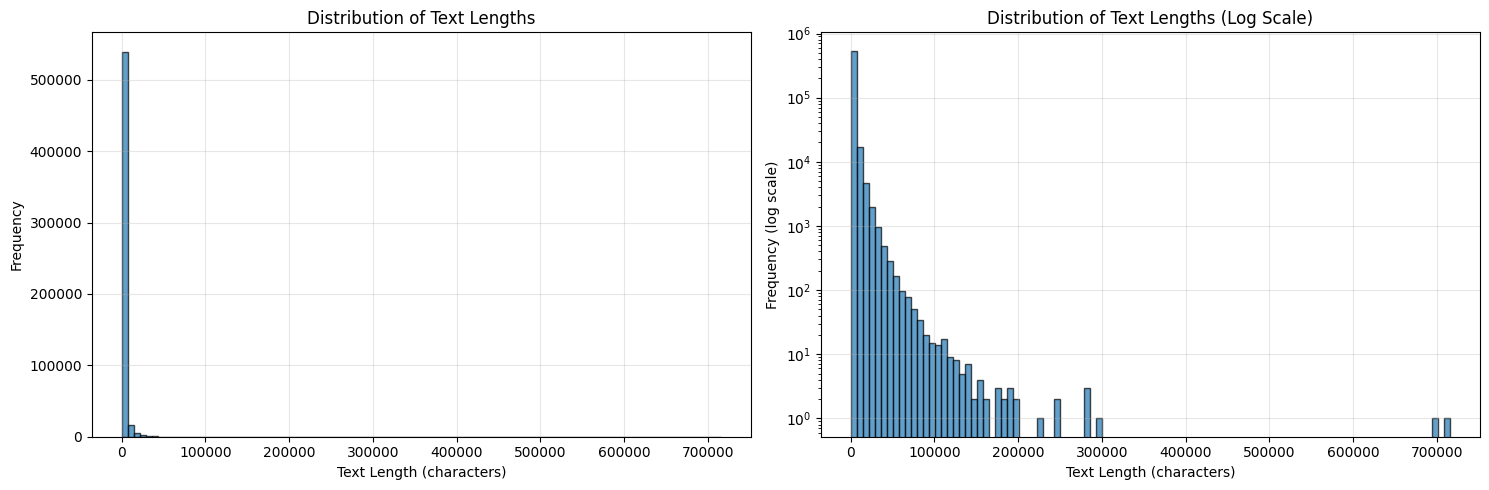

텍스트 길이 통계:
  평균: 1871.8자
  중앙값: 727.0자
  최소값: 200자
  최대값: 715,796자
  25% 분위수: 383.0자
  75% 분위수: 1671.0자


In [131]:
# 텍스트 길이 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 히스토그램
axes[0].hist(df_cleaned['text_length'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Text Length (characters)')  # 텍스트 길이 (문자 수)
axes[0].set_ylabel('Frequency')  # 빈도
axes[0].set_title('Distribution of Text Lengths')  # 텍스트 길이 분포
axes[0].grid(True, alpha=0.3)

# 로그 스케일 히스토그램
axes[1].hist(df_cleaned['text_length'], bins=100, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Text Length (characters)')  # 텍스트 길이 (문자 수)
axes[1].set_ylabel('Frequency (log scale)')  # 빈도 (로그 스케일)
axes[1].set_title('Distribution of Text Lengths (Log Scale)')  # 텍스트 길이 분포 (로그 스케일)
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 통계 출력
print("텍스트 길이 통계:")
print(f"  평균: {df_cleaned['text_length'].mean():.1f}자")
print(f"  중앙값: {df_cleaned['text_length'].median():.1f}자")
print(f"  최소값: {df_cleaned['text_length'].min():,}자")
print(f"  최대값: {df_cleaned['text_length'].max():,}자")
print(f"  25% 분위수: {df_cleaned['text_length'].quantile(0.25):.1f}자")
print(f"  75% 분위수: {df_cleaned['text_length'].quantile(0.75):.1f}자")


In [ ]:
# 그래프로 보고싶음 (다만 한국어 폰트가 없어서 영어로 작성해야함.)

## Hugging Face 업로드 (선택사항)

정제된 데이터를 Hugging Face에 업로드하려면 아래 셀을 실행하세요.


In [132]:
# Hugging Face에 정제된 데이터 업로드
from src.data.rag_dataset_creator import upload_cleaned_dataset_to_hf
import json

# 메타데이터 로드
metadata_file = output_dir / "metadata.json"
with open(metadata_file, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

# Hugging Face 업로드 설정
dataset_name = "kowiki-cleaned"  # 데이터셋 이름
version = "v1.0"  # 버전 태그

print(f"업로드 설정:")
print(f"  데이터셋 이름: {dataset_name}")
print(f"  버전: {version}")
print(f"  출력 디렉토리: {output_dir}")
print(f"  Parquet 파일: {output_dir / 'cleaned_pages.parquet'}")

# 업로드 실행
print(f"\n{'='*60}")
print("Hugging Face 업로드 시작...")
print(f"{'='*60}\n")

upload_cleaned_dataset_to_hf(
    output_dir=output_dir,
    dataset_name=dataset_name,
    metadata=metadata,
    version=version
)

print(f"\n{'='*60}")
print("✓ Hugging Face 업로드 완료!")
print(f"{'='*60}")

업로드 설정:
  데이터셋 이름: kowiki-cleaned
  버전: v1.0
  출력 디렉토리: /data/ephemeral/home/T8001/pro-nlp-generationfornlp-nlp-07/data/cleaned_datasets
  Parquet 파일: /data/ephemeral/home/T8001/pro-nlp-generationfornlp-nlp-07/data/cleaned_datasets/cleaned_pages.parquet

Hugging Face 업로드 시작...



Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Created dataset repository: NLP-07-ODQA/kowiki-cleaned
Uploading dataset card...

Uploading cleaned dataset...


Uploading the dataset shards:   0%|          | 0/5 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

...

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

✓ Uploaded 565,484 cleaned pages

Uploading metadata...

Dataset uploaded successfully!
URL: https://huggingface.co/datasets/NLP-07-ODQA/kowiki-cleaned

✓ Hugging Face 업로드 완료!
